In [4]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import generate_graph

In [6]:
from pathlib import Path
import os
import sys

project_root = Path.cwd().resolve().parents[1]
print(project_root)
sys.path.insert(0, str(project_root))

import lib.dataloader as dl


/vol/data/immuneML/cmsb26_project7


In [7]:
df = dl.load_kaggle_dataset("dataset_8")
df

Loading Kaggle dataset: dataset_8
Train path: /vol/data/keggel/train_datasets/train_datasets/train_dataset_8/
Loading cached dataset from /vol/data/keggel/train_datasets/train_datasets/train_dataset_8//_dataset.pkl...


,junction_aa,templates,sample,filename,label_positive,study_group_description,sex,age
0,CAAAGEDGYTF,2,e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
1,CAAAGGDNPTDTQYF,1,e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
2,CAAAIAEGYNEQFF,1,e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
3,CAAAPEGIYGYTF,1,e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
4,CAAAQSGGADTQYF,1,e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
...,...,...,...,...,...,...,...,...
93636518,YASRGRAHNQPQHF,1,d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866
93636519,YASSRQGGSYEQYF,1,d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866
93636520,YASTSGGNQPQHF,1,d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866
93636521,YAWSVFELVIAPGTGTEAFF,1,d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866


In [8]:
df = generate_graph.top_percent_cutoff(df, p=0.01)
df = df.reset_index(drop=True)
df

,junction_aa,templates,sample,filename,label_positive,study_group_description,sex,age,cummulative_perc
0,CAEVREVPYEQYF,4,e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243,0.991695
1,CAFLTSGGAETQYF,11,e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243,0.998952
2,CAFSPTRTGELFF,7,e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243,0.997348
3,CAGAEGRNTEAFF,4,e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243,0.991695
4,CAGEGDRVNYGYTF,4,e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243,0.991695
...,...,...,...,...,...,...,...,...,...
1234880,CSVGVGENTEAFF,11,d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866,0.998460
1234881,CSVRIGTGNTGELFF,4,d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866,0.993724
1234882,CSVSRRGQGKETQYF,7,d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866,0.996953
1234883,CSVTPGLAGGREQFF,6,d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866,0.996506


In [5]:
df["sample"].value_counts()

sample
246ca03e43cc3f7cfa3ed5a15e4303b3    8321
6315ac52f03355b55bbf5b1fc7d97f14    5201
4cb9cd4877254d6b367621306890328d    4070
a46528b1202b492820a0548daf89a899    3421
2403d512cf7ae6f8e768b2fa75b6a487    3398
                                    ... 
73774725e460b4b29e0a8a85833c5feb     553
0ac44b513e1cd6f803084a2cf220ecf2     537
3aaa1f17bfeff7f99e337f67fe5f37d1     520
bb3ecd98a4167666022f35e7c4ac249d     514
c3eff0c5d0c677b4e17ec09b9e72dc58     503
Name: count, Length: 908, dtype: int64

In [11]:
import numpy as np

import encoding.tcr_bert as tb

df_enc = tb.encode_sequences(df, seq_col="junction_aa", max_length=30)

['C A E V R E V P Y E Q Y F', 'C A F L T S G G A E T Q Y F', 'C A F S P T R T G E L F F', 'C A G A E G R N T E A F F', 'C A G E G D R V N Y G Y T F', 'C A G G T S L L M G T Q Y F', 'C A G P P V W R G N R Q S Y E Q Y F', 'C A G S G E P T D T Q Y F', 'C A H G T E A S P L H F', 'C A I A A F K L G Q G K I G E L F F', 'C A I G G Q G T D T Q Y F', 'C A I R G T M A G S T N T G E L F F', 'C A I R S T G G A K S F F', 'C A I S D G T S A S Y E Q Y F', 'C A I S D S W T T S V G E L F F', 'C A I S D W T S G T S S T D T Q Y F', 'C A I S E F G G R D N E Q F F', 'C A I S E F K G L A T S T D T Q Y F', 'C A I S E G G T S G D Y G N E Q F F', 'C A I S E G S D T T G E L F F']
['C S A S L T A G L I Y G Y T F', 'C S A S P I S G G D Y N E Q F F', 'C S A S R S F F', 'C S A S S G T P S Y N E Q F F', 'C S A T G T S S Y N E Q F F', 'C S A T P T G Q M G K E T Q Y F', 'C S A T S G G A G D R N E Q F F', 'C S A V G S E N Q P Q H F', 'C S A V V S G T G E L F F', 'C S F R V S H S Y N E Q F F', 'C S T Q T G D T E A F F',

Encoding sequences: 100%|██████████| 1206/1206 [19:34<00:00,  1.03it/s]


In [ ]:
# save mask and embeddings

_, _, embeddings = df_enc

save_path = "/vol/data/keggel/train_datasets/train_datasets/train_dataset_8"

np.save(save_path + "/embeddings.npy", embeddings)


In [ ]:
import numpy as np
save_path = "/vol/data/keggel/train_datasets/train_datasets/train_dataset_8"

embeddings = np.load(save_path + "/embeddings.npy")

In [16]:
df_simplified = generate_graph.native_node_merge(df, embeddings, 100)

Samples processed: 1
Samples processed: 2
Samples processed: 3
Samples processed: 4
Samples processed: 5
Samples processed: 6
Samples processed: 7
Samples processed: 8
Samples processed: 9
Samples processed: 10
Samples processed: 11
Samples processed: 12
Samples processed: 13
Samples processed: 14
Samples processed: 15
Samples processed: 16
Samples processed: 17
Samples processed: 18
Samples processed: 19
Samples processed: 20
Samples processed: 21
Samples processed: 22
Samples processed: 23
Samples processed: 24
Samples processed: 25
Samples processed: 26
Samples processed: 27
Samples processed: 28
Samples processed: 29
Samples processed: 30
Samples processed: 31
Samples processed: 32
Samples processed: 33
Samples processed: 34
Samples processed: 35
Samples processed: 36
Samples processed: 37
Samples processed: 38
Samples processed: 39
Samples processed: 40
Samples processed: 41
Samples processed: 42
Samples processed: 43
Samples processed: 44
Samples processed: 45
Samples processed: 

In [17]:
df_simplified

,cluster,templates,cluster_embedding,sample,filename,label_positive,study_group_description,sex,age
0,0,60,"[1.4897695, -0.9592489, 0.9256646, 0.2911301, ...",e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
1,1,530,"[1.5381337, -0.74105895, -0.015110701, -0.4375...",e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
2,2,122,"[0.04846883, 0.096212685, -0.42301327, 0.11790...",e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
3,3,237,"[1.5034612, -0.28868496, -0.2677366, -0.354199...",e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
4,4,60,"[0.46216345, -1.681366, 1.281286, -1.1508987, ...",e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
...,...,...,...,...,...,...,...,...,...
90795,95,21,"[-0.15114224, -0.95953125, -0.27641097, 0.9051...",d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866
90796,96,12,"[0.68714935, -0.088018, -0.35311532, 0.1782018...",d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866
90797,97,16,"[1.1566194, -0.065502316, -0.09521803, 0.97548...",d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866
90798,98,24,"[1.0862025, -0.016569883, 0.5030459, 0.1407640...",d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866


In [18]:
df_simplified.to_pickle("/vol/data/keggel/train_datasets/train_datasets/train_dataset_8/_dataset_100.pkl")


0     [1.4897695, -0.9592489, 0.9256646, 0.2911301, ...
1     [1.5381337, -0.74105895, -0.015110701, -0.4375...
2     [0.04846883, 0.096212685, -0.42301327, 0.11790...
3     [1.5034612, -0.28868496, -0.2677366, -0.354199...
4     [0.46216345, -1.681366, 1.281286, -1.1508987, ...
                            ...                        
95    [0.5983847, -0.81711113, -0.4163469, -0.531923...
96    [1.4480776, -0.98126864, 0.5867521, -0.7770057...
97    [-0.38258278, -0.23580599, 0.2976489, 0.376816...
98    [1.2548808, -0.5212938, -0.10051912, -0.471056...
99    [0.62309945, -0.34211227, -0.45507997, 0.27114...
Name: cluster_embedding, Length: 100, dtype: object

/vol/data/conda_envs/project_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


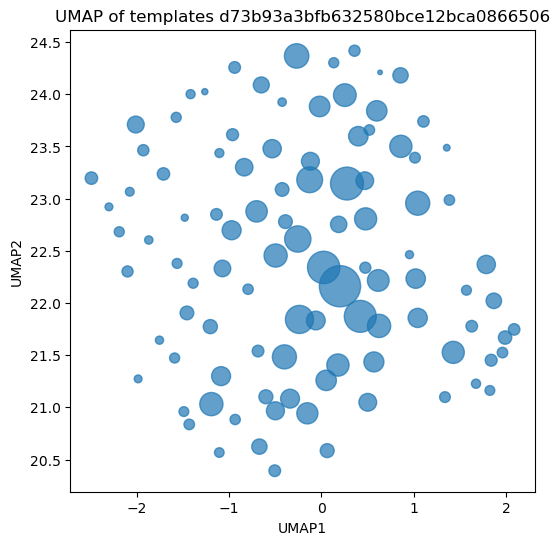

In [30]:
import pandas as pd
import numpy as np
import umap
import matplotlib.pyplot as plt

# Filter your dataframe
filtered = df_simplified[df_simplified["sample"] == "e441182799ba6725d4ae80e218ce3116"]

# Extract embeddings (make sure they are lists/arrays)
embeddings = np.array(filtered["cluster_embedding"].tolist())

# Initialize UMAP
reducer = umap.UMAP(n_neighbors=12, min_dist=0.1, random_state=42)

# Fit and transform
umap_embedding = reducer.fit_transform(embeddings)

# Optional: use a column for point size
# For example, using "counts" column or "size_metric"
sizes = filtered["templates"] if "templates" in filtered.columns else 10  # default size = 10

# Plot
plt.figure(figsize=(6,6))
plt.scatter(
    umap_embedding[:, 0],
    umap_embedding[:, 1],
    s=sizes,        # point sizes
    alpha=0.7
)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP of templates d73b93a3bfb632580bce12bca0866506")
plt.show()
